In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error,

In [2]:
df = pd.read_csv("df_india.csv")

Need only continuous cases values and time

We cannot use ARMA model because our time series is not stationary.

In [3]:
arima_df = df[['date', 'new_cases_smoothed']].copy()
df['date'] = pd.to_datetime(df['date'])
arima_df = arima_df.set_index('date')

arima_df.head()

,new_cases_smoothed
date,
2020-01-30,0.142857
2020-01-31,0.142857
2020-02-01,0.142857
2020-02-02,0.285714
2020-02-03,0.428571


In [4]:
y = arima_df['new_cases_smoothed']

Sort out missing dates in the date range as its important its continuous in nature

In [5]:
split_date = '2021-01-30'

train = y[y.index < split_date]
test = y[(y.index >= split_date) & (y.index <= '2021-09-30')]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 366
Testing observations: 244


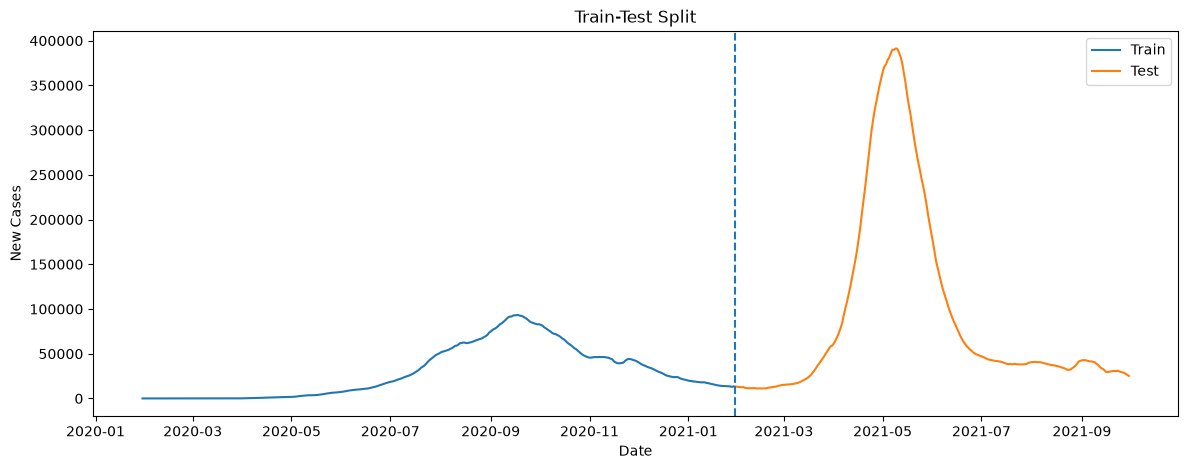

In [6]:
plt.figure(figsize=(14, 5))

train.index = pd.to_datetime(train.index)
test.index = pd.to_datetime(test.index)

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.axvline(
    pd.to_datetime(split_date),
    linestyle='--'
)

plt.xlabel("Date")
plt.ylabel("New Cases")
plt.title("Train-Test Split")

plt.legend()
plt.show()

In [7]:
adf_result = adfuller(train.dropna(), result_object=False)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -2.1064492907699424
p-value: 0.24192922977030146


Here, p-value < 0.05 so we reject the null hypothesis and it tells that the time series is stationary. We need to proceed to find order of differencing (d).

In [8]:
train_diff = train.diff()
train_diff_two = train.diff().diff()

Text(0.5, 1.0, 'ACF (d=2)')

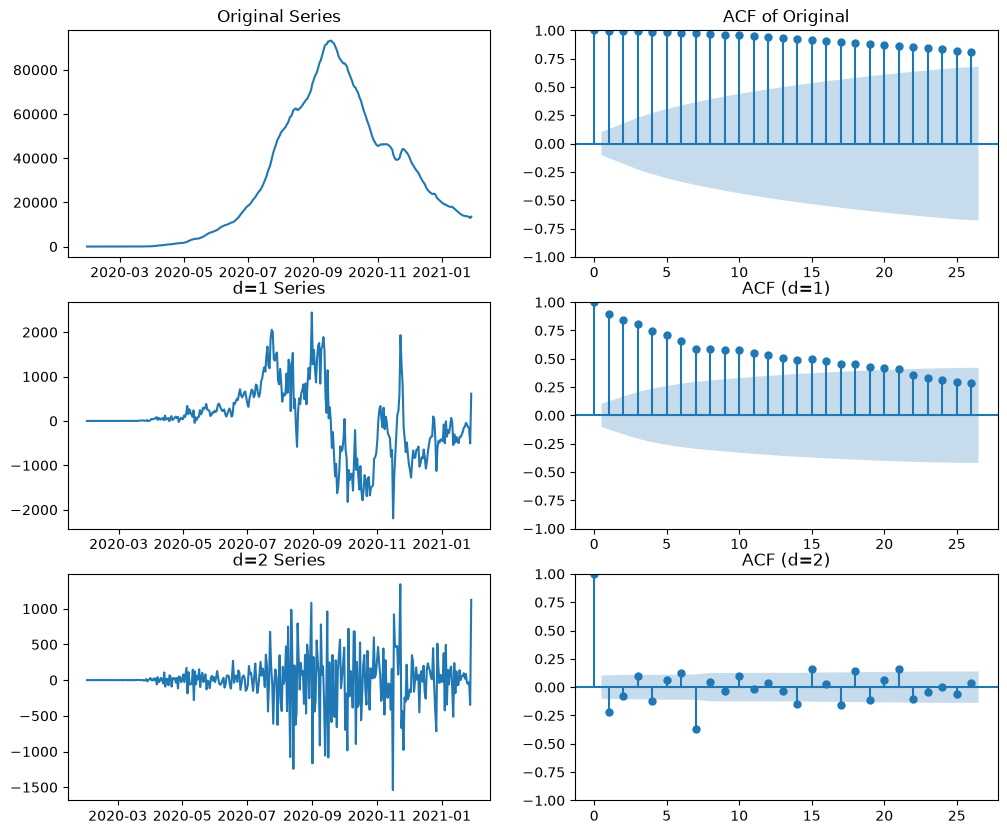

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12,10))

# Original Series
axes[0, 0].plot(train)
axes[0, 0].set_title("Original Series")
plot_acf(train, ax=axes[0, 1])
axes[0, 1].set_title("ACF of Original")

# 1st order diff
axes[1, 0].plot(train_diff)
axes[1, 0].set_title("d=1 Series")
plot_acf(train_diff.dropna(), ax=axes[1, 1])
axes[1, 1].set_title("ACF (d=1)")

# 2nd order diff
axes[2, 0].plot(train_diff_two.dropna())
axes[2, 0].set_title("d=2 Series")
plot_acf(train_diff_two.dropna(), ax=axes[2, 1])
axes[2, 1].set_title("ACF (d=2)")

It can be seen that at d=2 the series is becoming stationary, we shall try our ARIMA model with d=2.

In [10]:
adf_result_diff = adfuller(train_diff_two.dropna(), result_object=False)

print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])

ADF Statistic: -7.176748200328349
p-value: 2.714791528650371e-10


In [16]:
from pmdarima.arima.utils import ndiffs

## Adf Test
ndiffs(train_diff_two.dropna(), test='adf')  

# KPSS test
ndiffs(train_diff_two.dropna(), test='kpss') 

# PP test:
ndiffs(train_diff_two.dropna(), test='pp') 

0

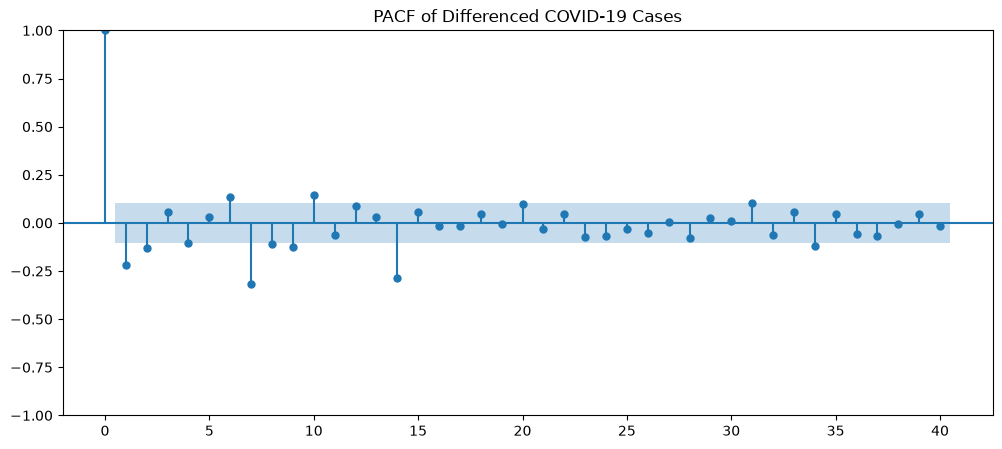

In [17]:
plt.figure(figsize=(12, 5))

plot_pacf(
    train_diff_two.dropna(),
    lags=40,
    ax=plt.gca(),
    method='ywm'
)

plt.title("PACF of Differenced COVID-19 Cases")

plt.show()

In [43]:
p_values = range(0, 4)
d_values = [2]
q_values = range(0, 4)

In [44]:
import warnings
results = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # This explicitly blocks all warnings from printing inside this loop
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore")
                    
                    model = ARIMA(train, order=(p, d, q))
                    # You can also add method_kwargs to help it converge faster
                    fitted_model = model.fit()

                    results.append({
                        'p': p,
                        'd': d,
                        'q': q,
                        'AIC': fitted_model.aic
                    })

            except Exception as e:
                # We can also silence the print statement for completely failed models
                # print(f"ARIMA({p},{d},{q}) failed: {e}")
                pass

In [45]:
arima_results = pd.DataFrame(results)

arima_results = arima_results.sort_values(
    'AIC'
)

arima_results.head(10)

,p,d,q,AIC
14,3,2,2,5201.748045
11,2,2,3,5210.796211
15,3,2,3,5226.569998
10,2,2,2,5230.024273
9,2,2,1,5242.650581
8,2,2,0,5242.883945
1,0,2,1,5243.297207
12,3,2,0,5243.633287
13,3,2,1,5244.381281
2,0,2,2,5244.560452


In [46]:
best_order = (
    int(arima_results.iloc[0]['p']),
    int(arima_results.iloc[0]['d']),
    int(arima_results.iloc[0]['q'])
)

print("Best ARIMA order:", best_order)

Best ARIMA order: (3, 2, 2)


In [47]:
arima_model = ARIMA(
    train,
    order=best_order
)

arima_fitted = arima_model.fit()

print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:     new_cases_smoothed   No. Observations:                  366
Model:                 ARIMA(3, 2, 2)   Log Likelihood               -2594.874
Date:                Wed, 30 Sep 2026   AIC                           5201.748
Time:                        19:47:03   BIC                           5225.131
Sample:                    01-30-2020   HQIC                          5211.042
                         - 01-29-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.8922      0.039    -48.815      0.000      -1.968      -1.816
ar.L2         -1.3887      0.062    -22.258      0.000      -1.511      -1.266
ar.L3         -0.3710      0.036    -10.296      0.0

In [48]:
forecast = arima_fitted.forecast(
    steps=len(test)
)

forecast = pd.Series(
    forecast,
    index=test.index
)

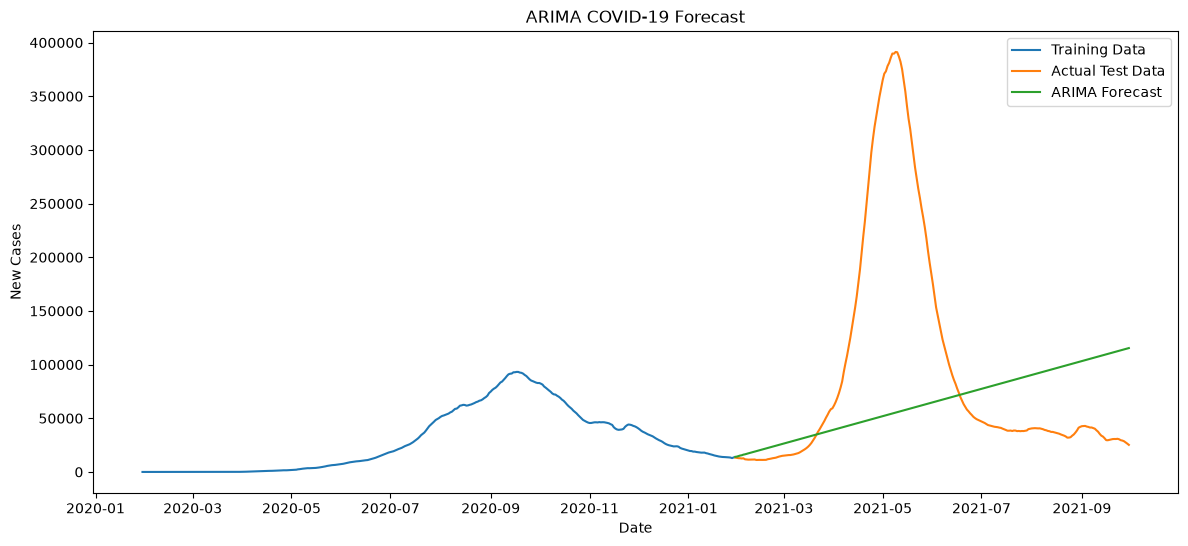

In [49]:
plt.figure(figsize=(14, 6))

plt.plot(
    train,
    label='Training Data'
)

plt.plot(
    test,
    label='Actual Test Data'
)

plt.plot(
    forecast,
    label='ARIMA Forecast'
)

plt.xlabel("Date")
plt.ylabel("New Cases")
plt.title("ARIMA COVID-19 Forecast")

plt.legend()

plt.show()

### Why ARIMA Fails on Epidemiological Wave Data

* **Inability to Model Exponential Growth:** ARIMA is a linear statistical model that relies on historical lags and moving averages. It lacks the mathematical mechanisms to predict the sudden, exponential contagion dynamics of a viral outbreak.
* **Convergence Over Long Horizons:** When forced to forecast months into the future without continuous short-term updates, ARIMA's predictions inherently lose the "memory" of recent fluctuations and converge into a simplistic straight-line drift.
* **Vulnerability to Structural Breaks:** The massive spike in the test data represents an unpredictable structural break (e.g., the introduction of a new variant). Autoregressive models cannot foresee these biological shifts purely from prior numeric trends. 
* **Need for Mechanistic Models:** Time-series models evaluate past data points, not transmission mechanics. Capturing these curves accurately requires compartmental models like SIR (Susceptible-Infectious-Recovered), which mathematically simulate actual population spread.

## Model Evaluation

In [55]:
mae = mean_absolute_error(
    test,
    forecast
)

print("MAE:", mae)

mse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("MSE:", mse)


MAE: 79589.79328035604
MSE: 120638.56243441039


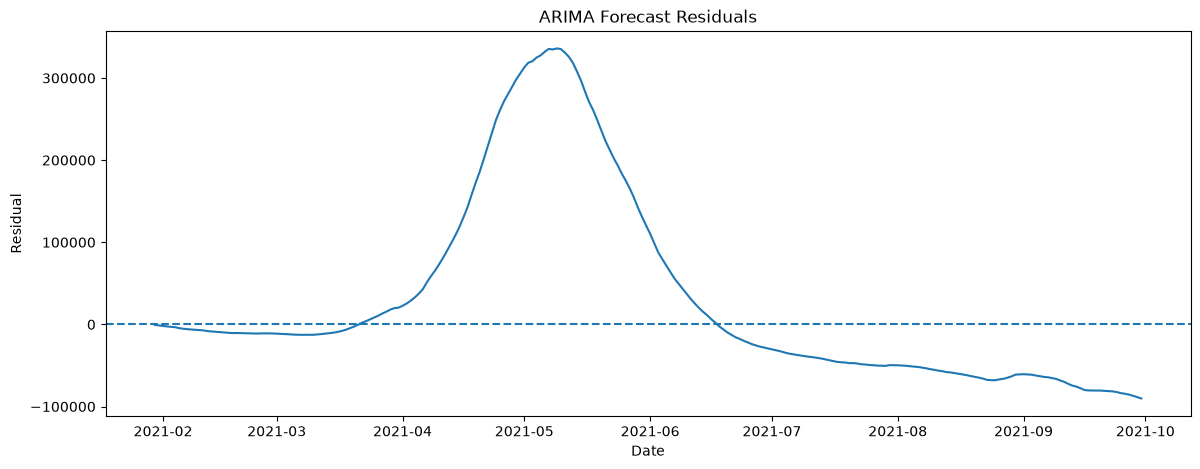

In [56]:
residuals = test - forecast

plt.figure(figsize=(14, 5))

plt.plot(residuals)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("ARIMA Forecast Residuals")

plt.show()

In [57]:
arima_predictions = pd.DataFrame({
    'date': test.index,
    'actual': test.values,
    'predicted': forecast.values
})

arima_predictions.head()

,date,actual,predicted
0,2021-01-30,13349.571,14058.221600
1,2021-01-31,13092.857,14309.712050
2,2021-02-01,12839.143,14795.818120
3,2021-02-02,12772.429,15267.836452
4,2021-02-03,12536.714,15548.139987


In [58]:
arima_predictions.to_csv(
    'arima_predictions.csv',
    index=False
)

In [59]:
model_results = pd.DataFrame({
    'Model': ['ARIMA'],
    'MAE': [mae],
    'MSE': [mse]
})

model_results

,Model,MAE,MSE
0,ARIMA,79589.79328,120638.562434
